# Experiment 6 — XGBoost Feature Engineering Playground

Sandbox for exploring feature engineering on top of the existing XGBoost counterfactual pipeline.

Current production features (`XGB_FEATURES`):
- `average_watts` — rider power output
- `average_grade` — segment grade %
- `doy_sin` / `doy_cos` — cyclical day-of-year (seasonality)
- `ride_index` — days since first recorded effort (fitness trend proxy)

**Goal:** experiment with candidate features and see whether they improve out-of-sample speed prediction before promoting them into `src/bike_delta.py`.

## 1. Imports

In [6]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

from src.database import init_db, load_efforts, load_segments, load_bikes
from src.bike_delta import (
    prepare_delta_dataset,
    XGB_FEATURES,
    fit_xgb_speed_model,
    apply_model_to_bike,
)
from src.analytics import filter_outliers_by_power_speed

sns.set_theme(style="whitegrid", palette="Set2")
print("Imports OK")
print(f"Current XGB_FEATURES: {XGB_FEATURES}")

Imports OK
Current XGB_FEATURES: ['average_watts', 'average_grade', 'doy_sin', 'doy_cos', 'ride_index']


## 2. Load and Inspect Data

In [7]:
init_db()
raw_efforts = load_efforts()
segments    = load_segments()
bikes_df    = load_bikes()
bikes_dict  = bikes_df[0]

df_raw = prepare_delta_dataset(raw_efforts, segments, bikes_dict)
df, _  = filter_outliers_by_power_speed(df_raw, z_threshold=2.0)

print(f"Efforts after outlier filter: {len(df):,}")
print(f"Bikes: {df['bike_name'].unique().tolist()}")
df.head()

Efforts after outlier filter: 1,347
Bikes: ['Titanium Horse', 'Drew bike', 'nan', 'Canyon Aeroad CF SLX', 'Specialized Tarmac SL8']


,effort_id,segment_id,activity_id,gear_id,start_date,elapsed_time,moving_time,average_watts,average_heartrate,bike_name,...,average_grade,segment_type,segment_type_detail,speed_kmh,speed_per_cbrt_watt,ride_index,doy_sin,doy_cos,is_outlier,z_score
2,2738902926332015334,16679746,4036869360,b7576250,2020-09-09T21:21:46Z,248,248,189.7,NaN,Titanium Horse,...,0.0,flat,flat_long,33.876290,5.895764,0.0,-0.936881,-0.349647,False,1.237701
3,2738902926334544614,17163284,4036869360,b7576250,2020-09-09T21:25:17Z,70,70,258.7,NaN,Titanium Horse,...,2.2,ascent,ascent_shallow,28.563429,4.482754,0.0,-0.936881,-0.349647,False,1.386698
4,2738902926334964454,16679494,4036869360,b7576250,2020-09-09T21:13:03Z,148,148,229.3,NaN,Titanium Horse,...,0.0,flat,flat_long,36.038919,5.888035,0.0,-0.936881,-0.349647,False,1.528563
5,2838596387151570404,16955378,5454186917,b7576250,2021-06-11T22:43:19Z,1659,1261,105.2,NaN,Titanium Horse,...,0.1,flat,flat_long,22.401649,4.745421,275.0,0.345612,-0.938377,False,0.975555
6,2838596387152520676,16679746,5454186917,b7576250,2021-06-12T00:11:42Z,333,333,106.1,NaN,Titanium Horse,...,0.0,flat,flat_long,25.229189,5.329235,275.0,0.329408,-0.944188,False,0.153235


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 1347 entries, 2 to 1385
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   effort_id            1347 non-null   int64  
 1   segment_id           1347 non-null   int64  
 2   activity_id          1347 non-null   int64  
 3   gear_id              1339 non-null   str    
 4   start_date           1347 non-null   str    
 5   elapsed_time         1347 non-null   int64  
 6   moving_time          1347 non-null   int64  
 7   average_watts        1347 non-null   float64
 8   average_heartrate    1273 non-null   float64
 9   bike_name            1347 non-null   str    
 10  distance             1347 non-null   float64
 11  average_grade        1347 non-null   float64
 12  segment_type         1347 non-null   str    
 13  segment_type_detail  1347 non-null   str    
 14  speed_kmh            1347 non-null   float64
 15  speed_per_cbrt_watt  1335 non-null   float64
 16  ride

,effort_id,segment_id,activity_id,elapsed_time,moving_time,average_watts,average_heartrate,distance,average_grade,speed_kmh,speed_per_cbrt_watt,ride_index,doy_sin,doy_cos,z_score
count,1.347000e+03,1.347000e+03,1.347000e+03,1347.000000,1347.000000,1347.000000,1273.000000,1347.000000,1347.000000,1347.000000,1335.000000,1347.000000,1347.000000,1347.000000,1298.000000
mean,3.378398e+18,1.839492e+07,1.519539e+10,578.970304,571.135857,257.798218,137.626473,4552.997699,0.496437,29.511211,4.891409,1764.225687,0.063199,-0.172732,-0.047924
std,7.496000e+16,9.608807e+06,1.808089e+09,502.683823,491.897782,104.156304,17.219048,3790.084004,1.969523,6.201948,2.886909,206.799296,0.738247,0.649521,0.882363
min,2.738903e+18,6.112560e+05,4.036869e+09,29.000000,29.000000,0.000000,63.900000,368.700000,-8.300000,9.497975,1.573117,0.000000,-0.999769,-0.999963,-1.953385
25%,3.349405e+18,1.667936e+07,1.424280e+10,81.000000,81.000000,209.350000,124.800000,612.400000,0.000000,26.075057,4.202792,1684.000000,-0.680773,-0.755493,-0.686340
50%,3.378032e+18,1.667975e+07,1.505757e+10,488.000000,479.000000,240.900000,134.200000,4620.400000,0.100000,28.679888,4.668603,1763.000000,0.128748,-0.317191,-0.111944
75%,3.418042e+18,2.027847e+07,1.627664e+10,1032.500000,1026.500000,285.200000,149.200000,7846.800000,0.700000,32.131084,5.060194,1874.000000,0.819007,0.421101,0.551348
max,3.492359e+18,3.711810e+07,1.858979e+10,2042.000000,1776.000000,1003.400000,185.300000,11932.100000,8.400000,56.785263,58.145505,2079.000000,0.999917,0.996298,1.982624


## 3. Feature Engineering

Add candidate features here. The block below engineers a set of starting ideas — comment out / add freely.

**Candidate ideas:**
- `log_watts` — log transform to compress power outliers
- `watts_per_grade` — power efficiency on a given slope
- `distance_km` — segment length (longer = more aerodynamic drag matters)
- `elapsed_ratio` — elapsed / moving time (stop-time proxy)
- `heartrate` — fatigue / exertion proxy (when available)
- `week_of_year_sin/cos` — finer periodicity than doy
- `effort_count` — cumulative rides (fitness ramp proxy)

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add candidate features to the prepared dataset.
    Edit freely — comment out or add columns as you experiment.
    """
    out = df.copy()
    ts = pd.to_datetime(out["start_date"], errors="coerce", utc=True).dt.tz_convert(None)

    # ── Power transforms ──────────────────────────────────────────────────────
    out["log_watts"] = np.log1p(out["average_watts"])
    out["cbrt_watts"] = np.cbrt(out["average_watts"])

    # ── Interaction: power efficiency on a slope ──────────────────────────────
    safe_grade = out["average_grade"].replace(0, np.nan)
    out["watts_per_grade"] = out["average_watts"] / safe_grade.abs()

    # ── Segment length ────────────────────────────────────────────────────────
    if "distance" in out.columns:
        out["distance_km"] = out["distance"] / 1000.0

    # ── Pacing: elapsed vs moving time ───────────────────────────────────────
    if "elapsed_time" in out.columns and "moving_time" in out.columns:
        safe_moving = out["moving_time"].replace(0, np.nan)
        out["elapsed_ratio"] = out["elapsed_time"] / safe_moving

    # ── Heart rate (when available) ───────────────────────────────────────────
    if "average_heartrate" in out.columns:
        out["heartrate"] = out["average_heartrate"]

    # ── Finer cyclical seasonality (week of year) ─────────────────────────────
    woy = ts.dt.isocalendar().week.astype(float)
    out["woy_sin"] = np.sin(2 * np.pi * woy / 52.0)
    out["woy_cos"] = np.cos(2 * np.pi * woy / 52.0)

    # ── Cumulative effort count as fitness ramp proxy ─────────────────────────
    out = out.sort_values("start_date")
    out["effort_count"] = np.arange(1, len(out) + 1, dtype=float)

    # ── Month encoded cyclically ──────────────────────────────────────────────
    month = ts.dt.month.astype(float)
    out["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * month / 12.0)

    return out.reset_index(drop=True)


df_feat = engineer_features(df)

# Show the new columns alongside existing ones
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"New features added: {new_cols}")
df_feat[XGB_FEATURES + new_cols].describe()

New features added: ['log_watts', 'cbrt_watts', 'watts_per_grade', 'distance_km', 'elapsed_ratio', 'heartrate', 'woy_sin', 'woy_cos', 'effort_count', 'month_sin', 'month_cos']


,average_watts,average_grade,doy_sin,doy_cos,ride_index,log_watts,cbrt_watts,watts_per_grade,distance_km,elapsed_ratio,heartrate,woy_sin,woy_cos,effort_count,month_sin,month_cos
count,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000,856.000000,1347.000000,1347.000000,1273.000000,1347.000000,1347.000000,1347.000000,1.347000e+03,1347.000000
mean,257.798218,0.496437,0.063199,-0.172732,1764.225687,5.437377,6.226209,860.027629,4.552998,1.008142,137.626473,0.045187,-0.178225,674.000000,9.248003e-03,-0.181397
std,104.156304,1.969523,0.738247,0.649521,206.799296,0.700696,1.006584,959.436665,3.790084,0.041236,17.219048,0.735025,0.653185,388.989717,7.138436e-01,0.676872
min,0.000000,-8.300000,-0.999769,-0.999963,0.000000,0.000000,0.000000,0.000000,0.368700,1.000000,63.900000,-1.000000,-1.000000,1.000000,-1.000000e+00,-1.000000
25%,209.350000,0.000000,-0.680773,-0.755493,1684.000000,5.348773,5.937783,118.897727,0.612400,1.000000,124.800000,-0.748511,-0.822984,337.500000,-8.660254e-01,-0.866025
50%,240.900000,0.100000,0.128748,-0.317191,1763.000000,5.488524,6.222223,340.633929,4.620400,1.000000,134.200000,0.120537,-0.354605,674.000000,1.224647e-16,-0.500000
75%,285.200000,0.700000,0.819007,0.421101,1874.000000,5.656691,6.582383,1858.500000,7.846800,1.000000,149.200000,0.822984,0.354605,1010.500000,8.660254e-01,0.500000
max,1003.400000,8.400000,0.999917,0.996298,2079.000000,6.912146,10.011321,3514.000000,11.932100,1.575419,185.300000,1.000000,1.000000,1347.000000,1.000000e+00,1.000000


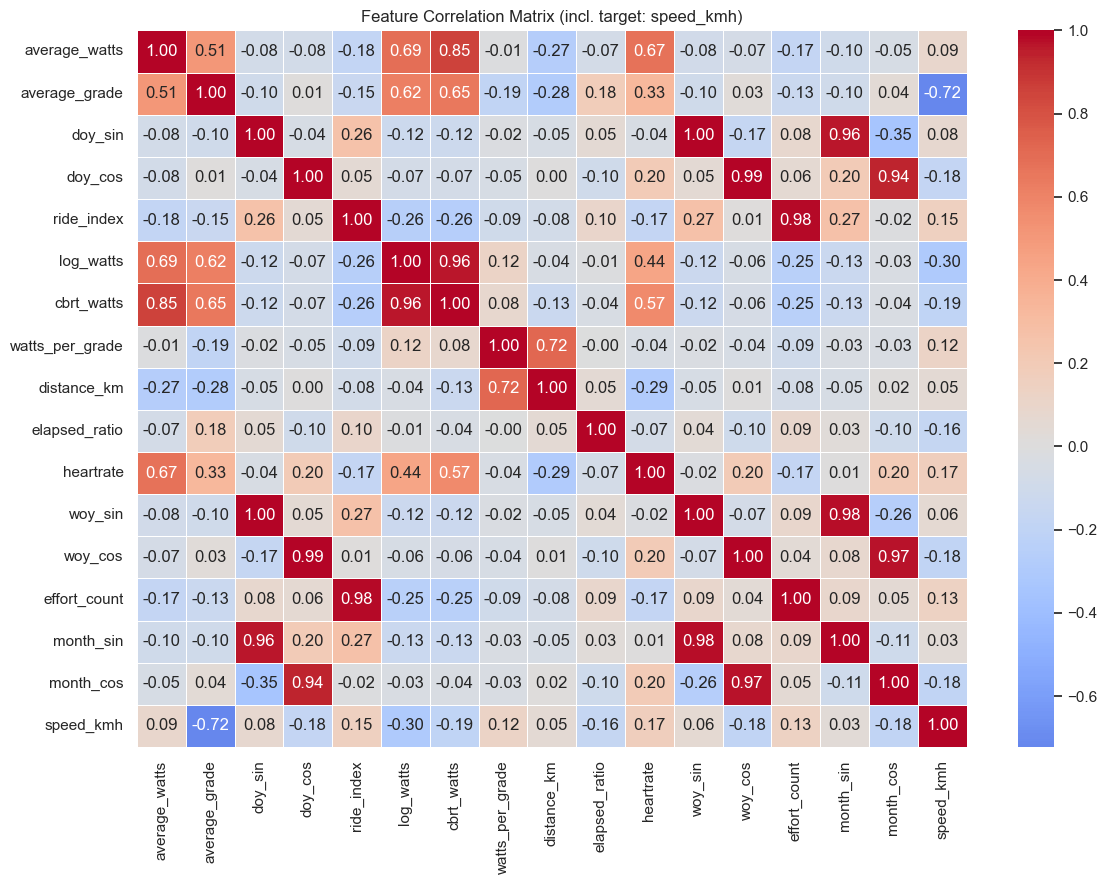

In [10]:
# Quick correlation heatmap of candidate features vs target (speed_kmh)
candidate_cols = XGB_FEATURES + new_cols + ["speed_kmh"]
corr = df_feat[candidate_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    center=0, cmap="coolwarm",
    linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Matrix (incl. target: speed_kmh)")
plt.tight_layout()
plt.show()

## 4. Train XGBoost Model

Trains per-bike models using the current production features and then with the expanded feature set so you can compare CV scores side by side.

In [11]:
# ── Edit these to swap in/out candidate features ──────────────────────────────
EXPERIMENTAL_FEATURES = XGB_FEATURES + [
    "log_watts",
    "cbrt_watts",
    "distance_km",
    "woy_sin",
    "woy_cos",
    "month_sin",
    "month_cos",
    # "watts_per_grade",  # noisy when grade ≈ 0 — uncomment to test
    # "elapsed_ratio",
    # "effort_count",
    # "heartrate",
]

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(feature_cols: list[str], df_in: pd.DataFrame) -> dict:
    """Return per-bike CV RMSE dict for the given feature set."""
    results = {}
    for bike in df_in["bike_name"].unique():
        sub = df_in[df_in["bike_name"] == bike].dropna(subset=feature_cols + ["speed_kmh"])
        if len(sub) < 10:
            continue
        X = sub[feature_cols].values
        y = sub["speed_kmh"].values
        model = xgb.XGBRegressor(**XGB_PARAMS)
        scores = cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
        results[bike] = -scores.mean()
    return results

baseline_rmse    = cv_rmse(XGB_FEATURES, df_feat)
experimental_rmse = cv_rmse(EXPERIMENTAL_FEATURES, df_feat)

compare = pd.DataFrame({
    "baseline_rmse":      baseline_rmse,
    "experimental_rmse":  experimental_rmse,
}).round(4)
compare["delta"] = (compare["experimental_rmse"] - compare["baseline_rmse"]).round(4)
compare["better"] = compare["delta"] < 0

print(compare)
compare

                        baseline_rmse  experimental_rmse   delta  better
Titanium Horse                 2.3252             2.2031 -0.1221    True
Drew bike                      2.9994             3.0519  0.0525   False
Canyon Aeroad CF SLX           2.3223             2.0230 -0.2993    True
Specialized Tarmac SL8         6.0399             6.0013 -0.0386    True


,baseline_rmse,experimental_rmse,delta,better
Titanium Horse,2.3252,2.2031,-0.1221,True
Drew bike,2.9994,3.0519,0.0525,False
Canyon Aeroad CF SLX,2.3223,2.0230,-0.2993,True
Specialized Tarmac SL8,6.0399,6.0013,-0.0386,True


## 5. Evaluate Model Performance

Feature importances + residual distributions for the experimental model.

In [ ]:
# Train a single full model (all data, no CV) for inspection
# Pick the bike with the most data as the representative model
bike_counts = df_feat.groupby("bike_name")["effort_id"].count().sort_values(ascending=False)
ref_bike = bike_counts.index[0]
print(f"Training inspection model on: {ref_bike!r}  ({bike_counts[ref_bike]} efforts)")

sub = df_feat[df_feat["bike_name"] == ref_bike].dropna(subset=EXPERIMENTAL_FEATURES + ["speed_kmh"])
X_all = sub[EXPERIMENTAL_FEATURES].values
y_all = sub["speed_kmh"].values

inspection_model = xgb.XGBRegressor(**XGB_PARAMS)
inspection_model.fit(X_all, y_all)

y_pred = inspection_model.predict(X_all)
rmse   = mean_squared_error(y_all, y_pred)
mae    = mean_absolute_error(y_all, y_pred)
print(f"Train RMSE: {rmse:.4f} km/h  |  MAE: {mae:.4f} km/h  (in-sample, for inspection only)")

Training inspection model on: 'Canyon Aeroad CF SLX'  (995 efforts)


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
# ── XGBoost built-in feature importance (gain) ───────────────────────────────
imp_gain = pd.Series(
    inspection_model.get_booster().get_score(importance_type="gain"),
    name="gain",
).reindex(EXPERIMENTAL_FEATURES, fill_value=0).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_gain.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance (XGB gain)")
axes[0].set_xlabel("Gain")

# ── Permutation importance (more reliable for correlated features) ────────────
perm = permutation_importance(
    inspection_model, X_all, y_all,
    n_repeats=20, random_state=42, scoring="neg_root_mean_squared_error",
)
perm_df = pd.Series(perm.importances_mean, index=EXPERIMENTAL_FEATURES, name="perm").sort_values(ascending=True)
perm_df.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Permutation Importance (neg RMSE impact)")
axes[1].set_xlabel("Mean importance")

plt.tight_layout()
plt.show()

In [ ]:
# ── Residual distribution ─────────────────────────────────────────────────────
residuals = y_all - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution (actual − predicted)")
axes[0].set_xlabel("Residual (km/h)")

axes[1].scatter(y_pred, residuals, alpha=0.4, s=20, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Predicted Speed")
axes[1].set_xlabel("Predicted speed_kmh")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}  |  std: {residuals.std():.4f}")

In [ ]:

# ── Speed vs Average Power (actual & XGB predicted) with R² ──────────────────
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual speed vs power, coloured by bike
for bike, grp in df_feat.groupby("bike_name"):
    axes[0].scatter(grp["average_watts"], grp["speed_kmh"],
                    alpha=0.4, s=18, label=bike)
axes[0].set_xlabel("Average Power (W)")
axes[0].set_ylabel("Speed (km/h)")
axes[0].set_title("Speed vs Avg Power — Actual (all bikes)")
axes[0].legend(fontsize=8)

# Right: XGB predicted vs actual for the reference bike (inspection_model)
sub_plot = df_feat[df_feat["bike_name"] == ref_bike].dropna(subset=EXPERIMENTAL_FEATURES + ["speed_kmh"])
r2_train = r2_score(y_all, y_pred)
axes[1].scatter(sub_plot["average_watts"], y_all,
                alpha=0.5, s=18, label="Actual", color="steelblue")
axes[1].scatter(sub_plot["average_watts"], y_pred,
                alpha=0.5, s=18, label="XGB Predicted", color="coral", marker="^")
axes[1].set_xlabel("Average Power (W)")
axes[1].set_ylabel("Speed (km/h)")
axes[1].set_title(f"Speed vs Avg Power — {ref_bike!r}\n(train R² = {r2_train:.3f})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Train R²: {r2_train:.4f}")


In [ ]:

# ── Per-bike model statistics (CV R², RMSE, MAE) ─────────────────────────────
from sklearn.model_selection import cross_val_score

stats_rows = []
for bike in df_feat["bike_name"].unique():
    sub = df_feat[df_feat["bike_name"] == bike].dropna(
        subset=EXPERIMENTAL_FEATURES + ["speed_kmh"]
    )
    if len(sub) < 10:
        continue
    X = sub[EXPERIMENTAL_FEATURES].values
    y = sub["speed_kmh"].values
    model = xgb.XGBRegressor(**XGB_PARAMS)

    cv_rmse_scores = cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    cv_r2_scores   = cross_val_score(model, X, y, cv=cv, scoring="r2")
    cv_mae_scores  = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")

    # Fit on all data for in-sample stats
    model.fit(X, y)
    y_hat = model.predict(X)

    stats_rows.append({
        "bike":            bike,
        "n_efforts":       len(sub),
        "cv_R²_mean":      round(cv_r2_scores.mean(), 4),
        "cv_R²_std":       round(cv_r2_scores.std(), 4),
        "cv_RMSE_mean":    round(-cv_rmse_scores.mean(), 4),
        "cv_RMSE_std":     round(cv_rmse_scores.std(), 4),
        "cv_MAE_mean":     round(-cv_mae_scores.mean(), 4),
        "train_R²":        round(r2_score(y, y_hat), 4),
        "train_RMSE":      round(mean_squared_error(y, y_hat), 4),
        "speed_mean_kmh":  round(y.mean(), 2),
        "speed_std_kmh":   round(y.std(), 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index("bike")
print("=== Per-bike XGBoost Model Statistics (experimental feature set) ===\n")
stats_df


---
### Scratch / Next steps

Use the cells below to try new things. Some ideas:
- Tune `XGB_PARAMS` (increase `max_depth`, try `min_child_weight`, `reg_alpha`)
- Add `segment_id` as a categorical feature to capture per-segment fixed effects
- Try `speed_per_cbrt_watt` as the target instead of raw `speed_kmh`
- Slice results by `segment_type` to see if certain features matter more on climbs vs flats

In [ ]:
# Scratch cell — play around here
# segment duration
# overall segment average speed?
# straightness
